In [1]:
from TdCARS import TdCARS
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
#import scienceplots
#plt.style.use(['science'])

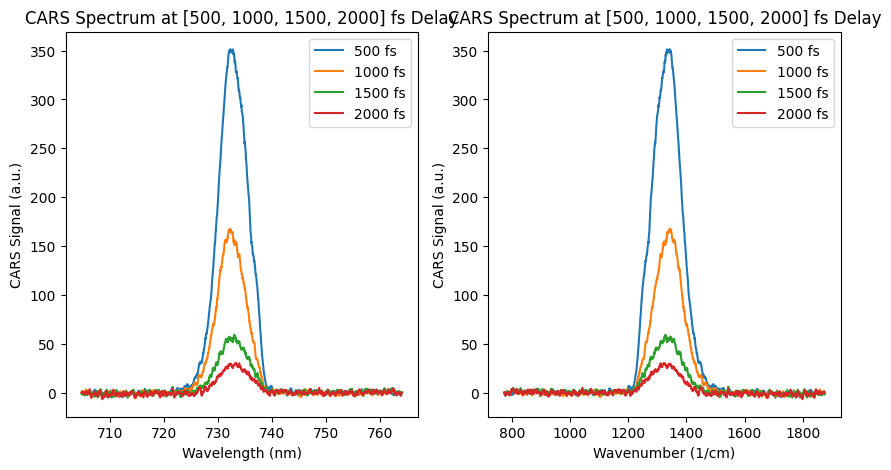

In [9]:
cars_file_path = r"D:\Academic\URI\Research\Data_and_Results\experimental_data\CARS\2026\May_28\RBD_6.dat"
CARS = TdCARS.from_file(cars_file_path)

td = [500, 1000, 1500, 2000]  # Time delay in fs
res = CARS.plot_spectra_at_td(td, show_plot=True, boxcar_window=10)

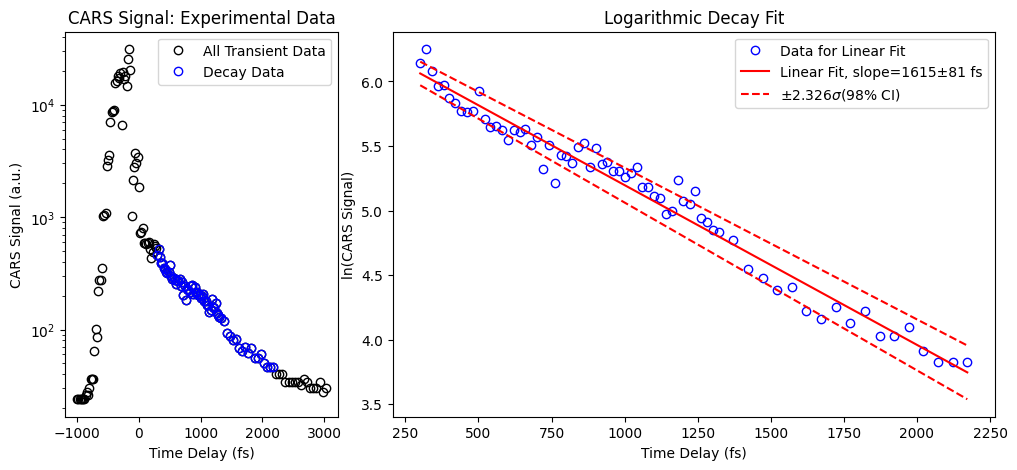

In [10]:
corrections = np.array([[120,100], [650,500], [30,30]])
CARS.correct_experimental_data(corrections)
td1,td2 = 300,2200 #Time delay range for fitting [fs]
T2, dT2 = CARS.get_T2(td1, td2, show_plot=True)

In [11]:
CARS.notes_df

,0,1
0,DET,Syncerity CCD
1,SMP,Protein RBD
2,P3 (TiS),117
3,P1 (OPO1),230
4,P2 (OPO2),200
5,Polarizations,All parallel
6,Ti-Sa,812
7,OPO1,1018
8,OPO2,1140
9,MONO,735


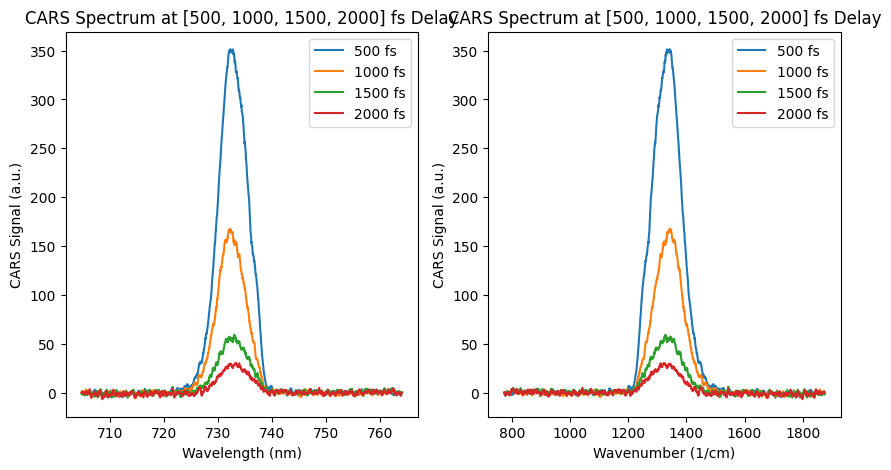

In [12]:
td = [500, 1000, 1500, 2000]  # Time delay in fs
res = CARS.plot_spectra_at_td(td, show_plot=True, boxcar_window=10)

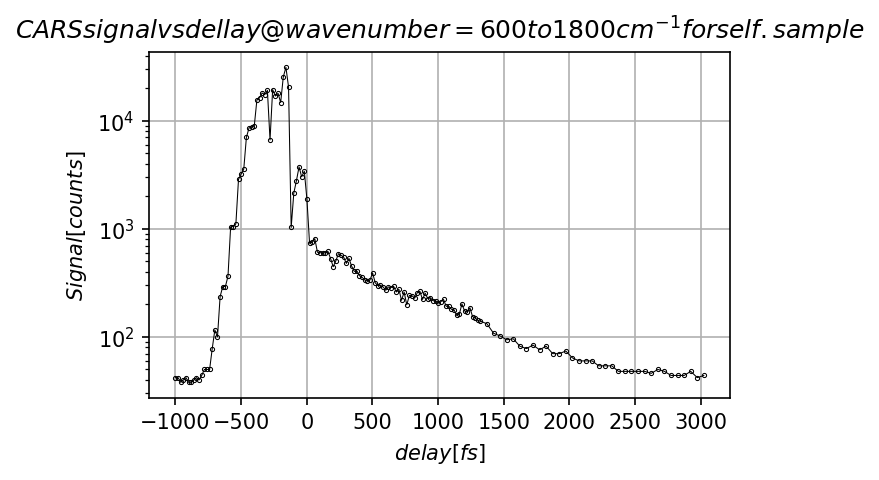

In [25]:
wn_target = [600,1800]  # Wavenumber in cm^-1
res = CARS.get_transient_at_wn(wn_target,showPlot=True)

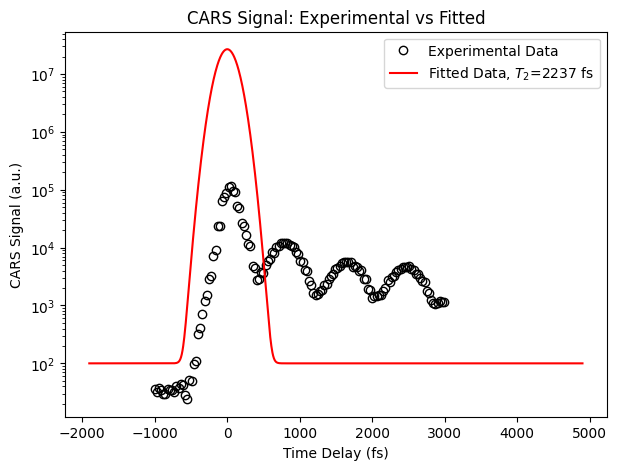

In [ ]:
CARS.tp1,CARS.tp2,CARS.tp3 = 260,260,220  # Pulse durations [fs]
CARS.tmin,CARS.tmax = -3000,6000  # Time delay range [fs]
CARS.floor = 100  # Baseline signal level
CARS.nuR1 = np.array([730,10])  # Raman shift frequencies [cm^-1]
CARS.T21 = np.array([T2,10])  # Dephasing times [fs]
CARS.A1 = np.array([1.9e25,0])  # Amplitudes of Raman modes [au]
CARS.phi1 = 0  # Phase of first Raman mode [rad]
    
td_fit, signal_fit = CARS.CARS_simulation_FG(showPlot=True)

c:\Users\dinus\OneDrive\Documents\Projects\Python\Python Physics\Optics\td_CARS_fit\TdCARS.py:241: RuntimeWarning: divide by zero encountered in log
  Z = np.log(spectra_sc_crop)


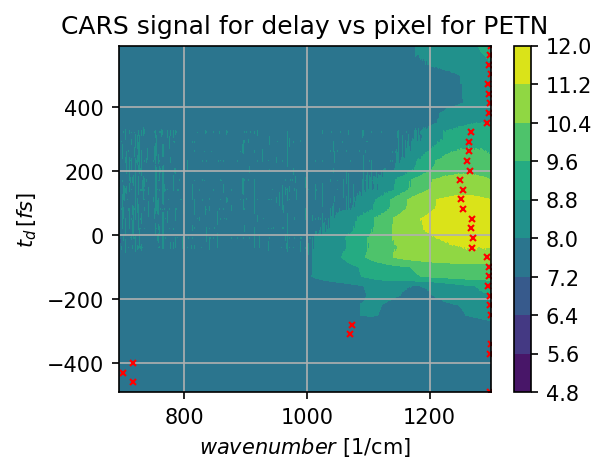

In [ ]:
Z = CARS.get_spectra_contour(show_plot=True, wn_lim=[650,1300], td_lim=[-500,600])

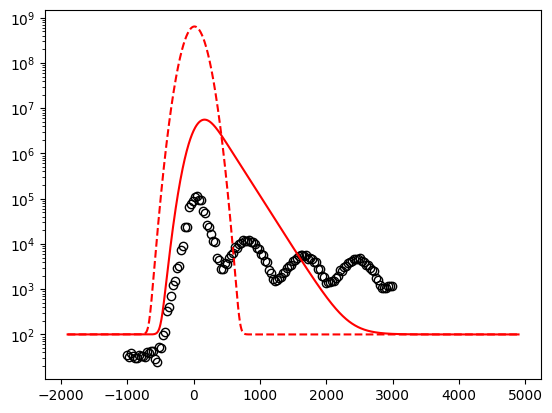

In [ ]:
td_exp, signal_exp = CARS.td_arr, CARS.signal_exp
plt.semilogy(td_exp, signal_exp, 'ko', mfc='none')
wl1, wl2 = 1000,1100
tp1, tp2, tp3 = 260,260,220
tmin, tmax = -3000,6000
floor = 100
nuR = np.array([1e7*(1/wl1-1/wl2),10])
T2 = np.array([377,10])
A = np.array([5e23,0])
phi = np.pi*0.5
res_CARS = TdCARS.from_params(wl1, wl2, tp1, tp2, tp3, tmin, tmax, floor, nuR, T2, A, phi)
td_fit, signal_fit = res_CARS.CARS_simulation_FG()
plt.semilogy(td_fit, signal_fit, 'r-')

tp1, tp2, tp3 = 260,260,220
T2 = np.array([10,10])
A = np.array([1.3e26,0])
res_CARS = TdCARS.from_params(wl1, wl2, tp1, tp2, tp3, tmin, tmax, floor, nuR, T2, A, 0)
td_fit2, signal_fit2 = res_CARS.CARS_simulation_FG()
plt.semilogy(td_fit2, signal_fit2, 'r--')

In [ ]:
signal_exp_log = np.log10(signal_exp)
sig_min = np.min(signal_exp_log)
sig_max = np.max(signal_exp_log)
index_at_sig_max = np.argmax(signal_exp_log)

In [ ]:
def lorentzian(x, A, x0, gamma, B):
    return A / (1 + ((x - x0) / gamma) ** 2) + B

def sinc2(x, A, x0, gamma, B):
    return A * np.sinc((x - x0) / gamma) ** 2 + B

def gaussian(x, A, x0, gamma, B):
    return A * np.exp(-((x - x0) / gamma) ** 2) + B

def sinc2_gaussian(x, A, x0, gamma_sinc, gamma_gauss, B):
    return A * np.sinc((x - x0) / gamma_sinc) ** 2 * np.exp(-((x - x0) / gamma_gauss) ** 2) + B

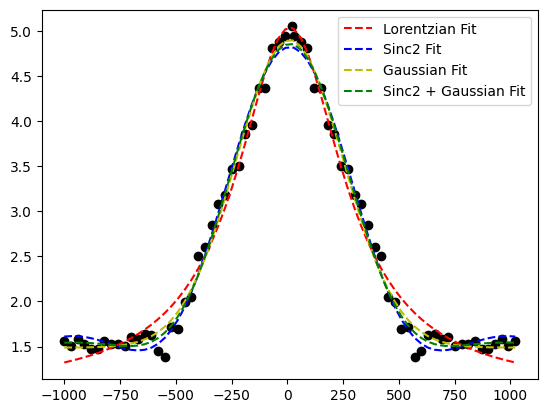

In [ ]:
    x = td_exp[td_exp < td_exp[index_at_sig_max]]
    y = signal_exp_log[td_exp < td_exp[index_at_sig_max]]
    x = np.concatenate([x, np.max(x)-np.flip(x[:-1])])
    y = np.concatenate([y, np.flip(y[:-1])])
    
    plt.plot(x,y, 'ko')
    
    popt, pcov = curve_fit(lorentzian, x, y, p0=[np.max(y),1,1,np.min(y)])
    plt.plot(x, lorentzian(x, *popt), 'r--', label='Lorentzian Fit')
    
    popt2, pcov2 = curve_fit(sinc2, x, y, p0=[np.max(y),0,500,np.min(y)])
    plt.plot(x, sinc2(x, *popt2), 'b--', label='Sinc2 Fit')
    
    popt3, pcov3 = curve_fit(gaussian, x, y, p0=[np.max(y),0,500,np.min(y)])
    plt.plot(x, gaussian(x, *popt3), 'y--', label='Gaussian Fit')
    
    popt4, pcov4 = curve_fit(sinc2_gaussian, x, y, p0=[np.max(y),0,500,500,np.min(y)])
    plt.plot(x, sinc2_gaussian(x, *popt4), 'g--', label='Sinc2 + Gaussian Fit')
    
    plt.legend()
    plt.show()

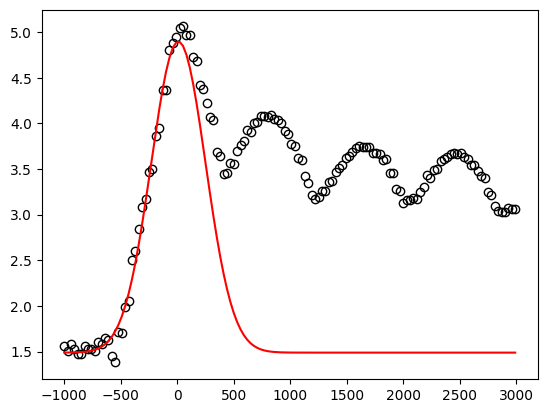

In [ ]:
plt.plot(td_exp, signal_exp_log, 'ko', mfc='none')
plt.plot(td_exp, gaussian(td_exp, *popt3), 'r-')

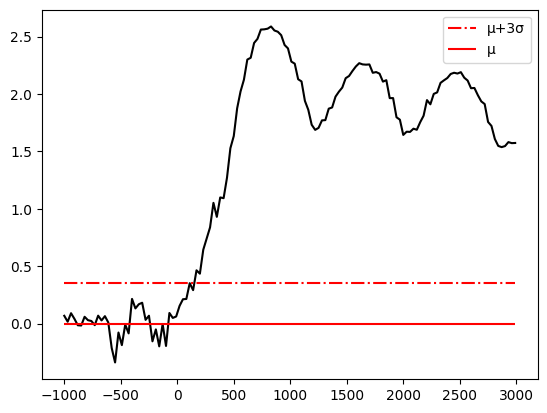

In [ ]:
xx = td_exp
yy = gaussian(xx, *popt3)
dyy = signal_exp_log-yy
std_dev_before_zero = np.std(dyy[xx < 0])
mean_before_zero = np.mean(dyy[xx < 0])
plt.plot(xx, dyy, 'k')
plt.hlines(mean_before_zero+3*std_dev_before_zero, np.min(xx), np.max(xx), 'r', linestyle='-.', label='μ+3σ')
plt.hlines(mean_before_zero, np.min(xx), np.max(xx), 'r', linestyle='-', label='μ')
plt.legend()
plt.show()

In [ ]:
td_rng = xx[(xx>0) & (dyy > mean_before_zero + 3 * std_dev_before_zero)]
print(f'Time range: {np.min(td_rng)} fs to {np.max(td_rng)} fs')

Time range: 171.0 fs to 2993.0 fs
